In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
parent_dir = 'results/trajs:360_blocks:3_imgs_2cams_909.691K_interp_0.85/ep:4400/image_model_img_task_enc_rob_enc'
# results/trajs:360_blocks:3_imgs_2cams_909.691K_interp_0.85/ep:4400/image_model_img_task_enc_rob_enc
file_path = os.path.join(parent_dir, 'all_states_image_model')

with open(file_path, 'rb') as f:
    data = pickle.load(f)

print('Type:', type(data))
print('Length (number of episodes):', len(data))

if len(data) > 0:
    print('\nFirst episode:')
    print('  Type:', type(data[0]))
    print('  Length (timesteps):', len(data[0]))
    
    if len(data[0]) > 0:
        print('\n  First timestep:')
        print('    Type:', type(data[0][0]))
        print('    Length (state dims):', len(data[0][0]))
        print('    Values:', data[0][0])
        
        print('\n  Last timestep:')
        print('    Values:', data[0][-1])

Type: <class 'list'>
Length (number of episodes): 18

First episode:
  Type: <class 'list'>
  Length (timesteps): 300

  First timestep:
    Type: <class 'list'>
    Length (state dims): 14
    Values: [1.5068886280059814, 1.1917660236358643, 1.2297476530075073, 1.3628121614456177, -0.5923159122467041, 1.1364721059799194, 0.5763422250747681, -0.03513689339160919, -0.03595095872879028, -0.01736246980726719, 0.04541519656777382, 0.013992867432534695, -0.035162974148988724, 0.014710971154272556]

  Last timestep:
    Values: [1.7659446001052856, 1.1824828386306763, 1.341204285621643, 1.4353423118591309, -0.491798460483551, 1.5462650060653687, 0.5919272899627686, 0.014454738236963749, 0.0049420311115682125, 0.006370470859110355, -0.004712402820587158, 0.0007455076556652784, 0.016437452286481857, -0.0028140610083937645]


In [8]:
# Select episode to plot
episode_idx = 1
episode_data = np.array(data[episode_idx])
veloc_scalar = 5

# Stored data at index k: [physical_{k+1}, vel_k]
# So: physical_joints[k] = physical at timestep k+1
#     velocities[k] = vel at timestep k
physical_joints = episode_data[:, :7]    # shape: (T, 7)
velocities = episode_data[:, 7:]          # shape: (T, 7)

# Reconstruct theory values:
# theory_{k+1} = physical_k + 5 * vel_k
# In stored indices: theory[k] = physical_joints[k-1] + 5 * velocities[k]
# For k=1 to T-1:
theory_joints = physical_joints[:-1] + veloc_scalar * velocities[1:]  # shape: (T-1, 7)

# Compare theory[k] with physical_joints[k] for k=1 to T-1
physical_for_comparison = physical_joints[1:]  # physical at k=1 to T-1

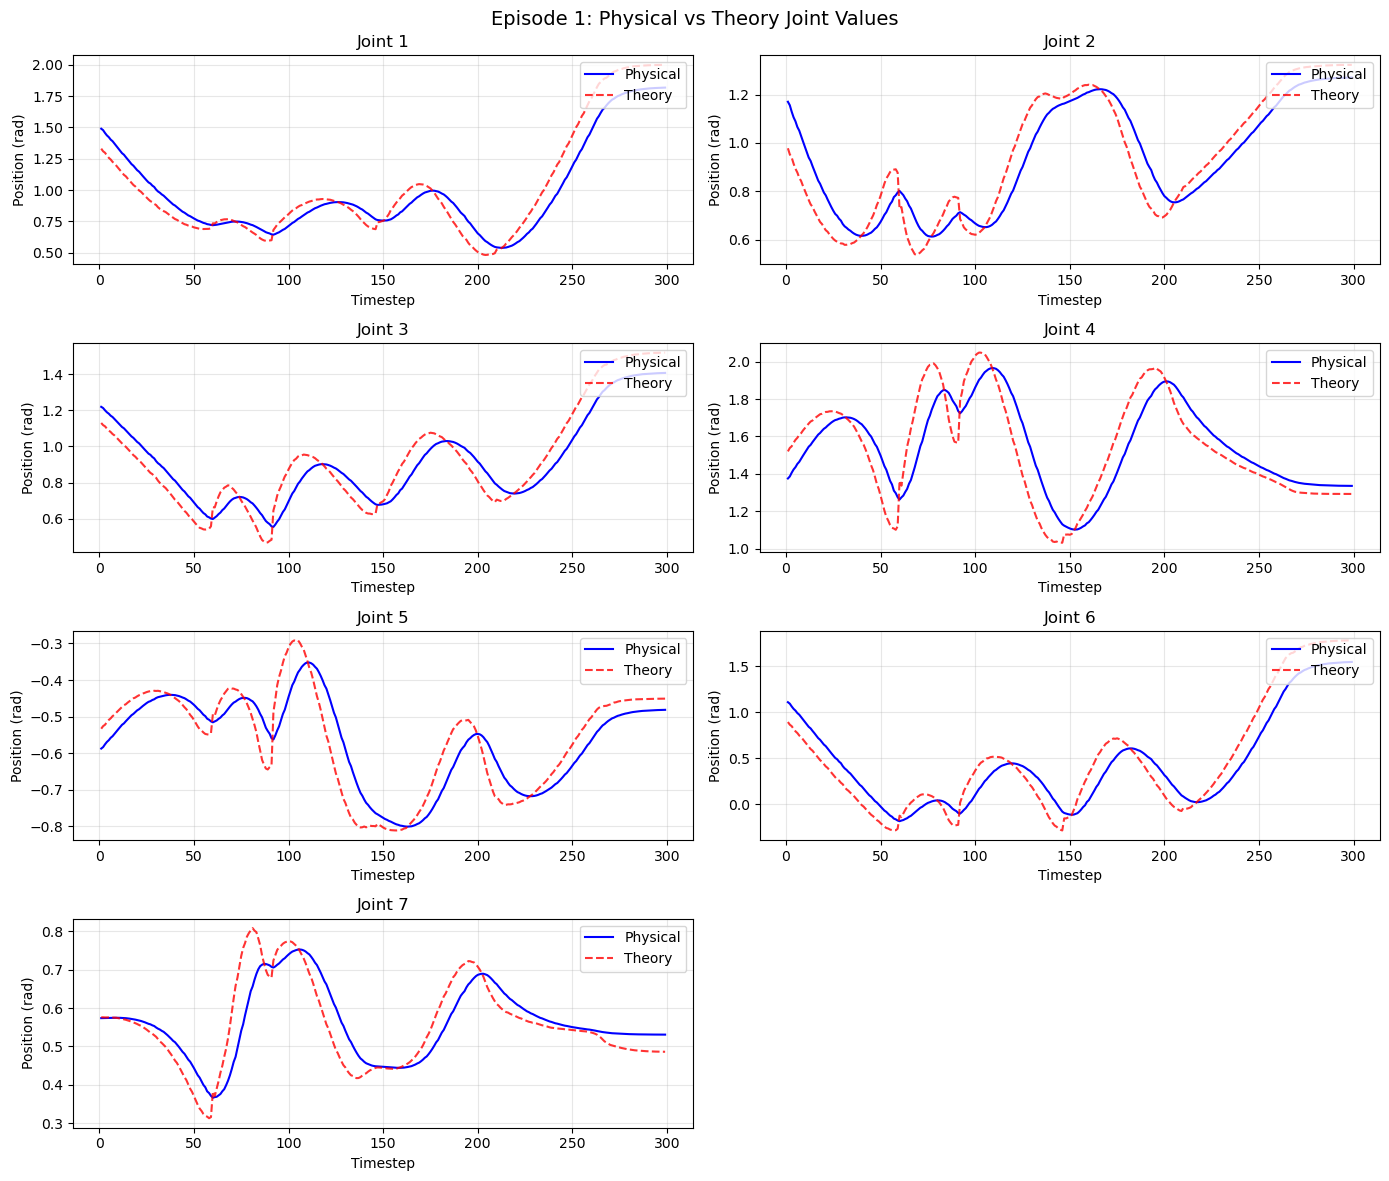

In [9]:
# Plot physical vs theory for each joint
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

timesteps = np.arange(1, len(physical_for_comparison) + 1)

for j in range(7):
    ax = axes[j]
    ax.plot(timesteps, physical_for_comparison[:, j], 'b-', label='Physical', linewidth=1.5)
    ax.plot(timesteps, theory_joints[:, j], 'r--', label='Theory', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Position (rad)')
    ax.set_title(f'Joint {j+1}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Hide the 8th subplot
axes[7].axis('off')

plt.suptitle(f'Episode {episode_idx}: Physical vs Theory Joint Values', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(parent_dir, f'physic_v_theory_ep{episode_idx}.png'))
plt.show()

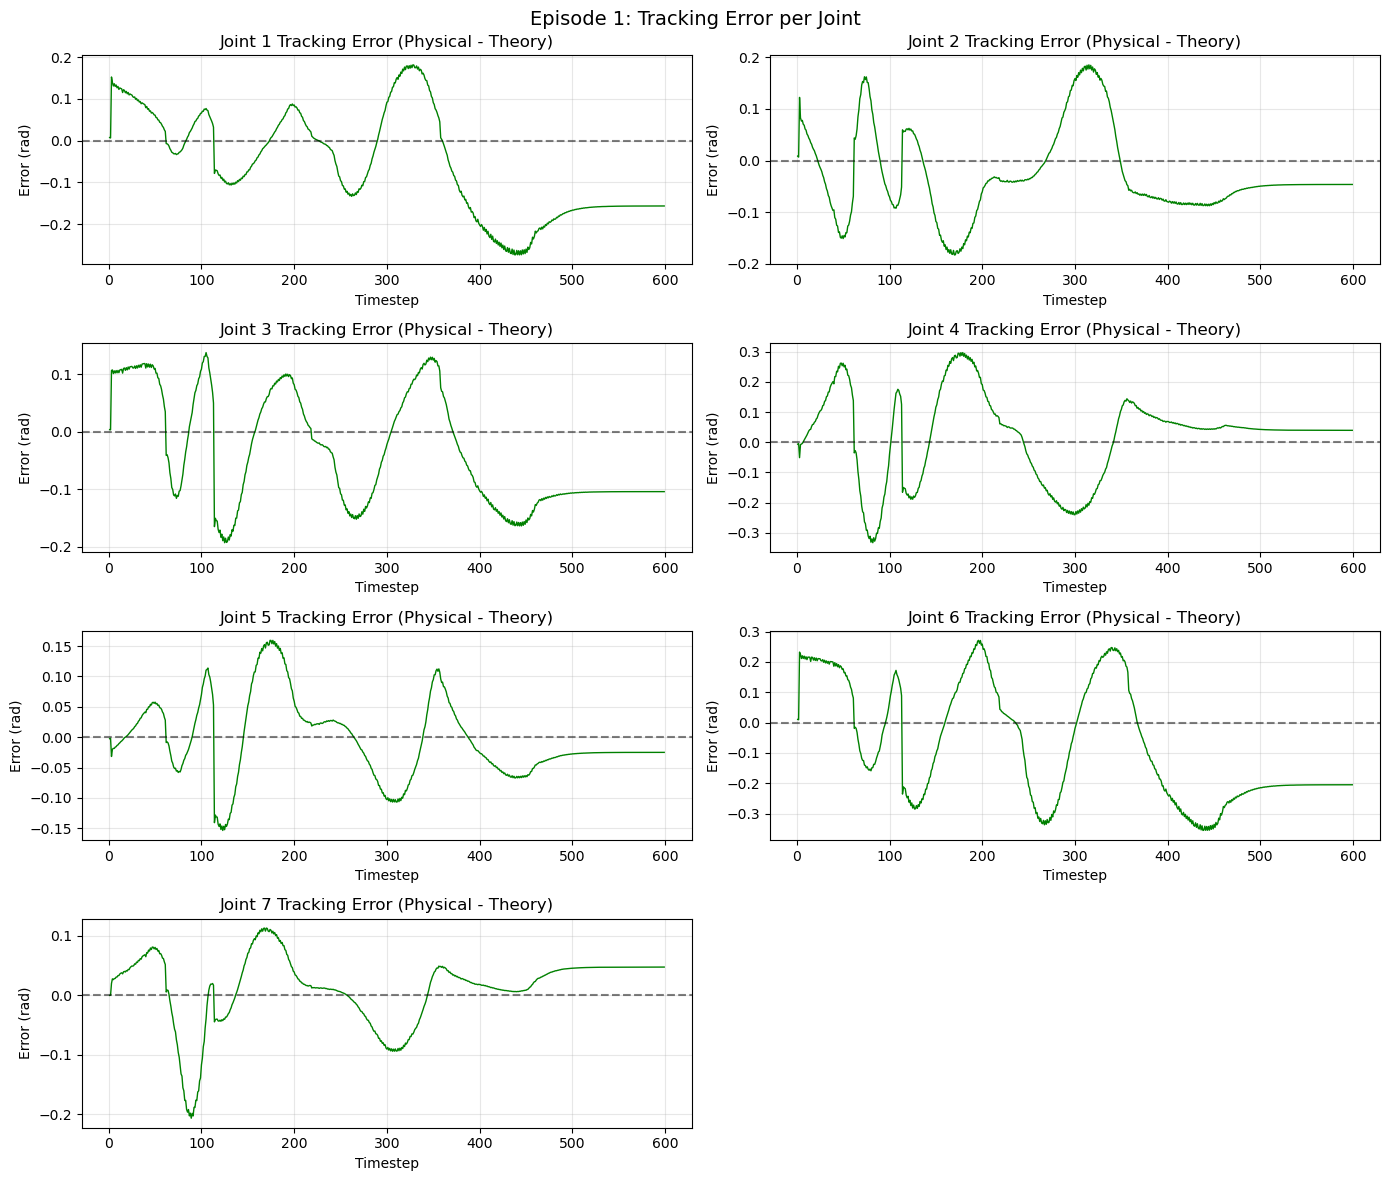

In [5]:
# Also show the tracking error (physical - theory)
fig2, axes2 = plt.subplots(4, 2, figsize=(14, 12))
axes2 = axes2.flatten()

for j in range(7):
    ax = axes2[j]
    error = physical_for_comparison[:, j] - theory_joints[:, j]
    ax.plot(timesteps, error, 'g-', linewidth=1)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Error (rad)')
    ax.set_title(f'Joint {j+1} Tracking Error (Physical - Theory)')
    ax.grid(True, alpha=0.3)

axes2[7].axis('off')
plt.suptitle(f'Episode {episode_idx}: Tracking Error per Joint', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(parent_dir, f'error_physic_v_theory_ep{episode_idx}.png'))
plt.show()

In [ ]:
# Plot joint positions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Joint positions
for j in range(7):
    axes[0].plot(physical_joints[:, j], label=f'Joint {j+1}')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Position (rad)')
axes[0].set_title(f'Episode {episode_idx} - Joint Positions')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Joint velocities
for j in range(7):
    axes[1].plot(velocities[:, j], label=f'Joint {j+1}')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Velocity (rad/s)')
axes[1].set_title(f'Episode {episode_idx} - Joint Velocities')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# x_des vs x_encoded

In [ ]:
# Load x_des (latent_reps) and x_encoded data
x_des_path = os.path.join(parent_dir, 'all_latent_reps')
x_encoded_path = os.path.join(parent_dir, 'all_x_encoded')

with open(x_des_path, 'rb') as f:
    all_x_des = pickle.load(f)

with open(x_encoded_path, 'rb') as f:
    all_x_encoded = pickle.load(f)

print('x_des (latent_reps):')
print('  Number of episodes:', len(all_x_des))
if len(all_x_des) > 0:
    print('  First episode timesteps:', len(all_x_des[0]))
    if len(all_x_des[0]) > 0:
        print('  Latent dim:', len(all_x_des[0][0]))
        # print(all_x_des[0][0])

print('\nx_encoded:')
print('  Number of episodes:', len(all_x_encoded))
if len(all_x_encoded) > 0:
    print('  First episode timesteps:', len(all_x_encoded[0]))
    if len(all_x_encoded[0]) > 0:
        print('  Latent dim:', len(all_x_encoded[0][0]))
        # print(all_x_encoded[0][0])

In [ ]:
def find_x_des_change_timesteps(x_des_arr, threshold=1e-7):
    """Find timesteps where x_des values change significantly.
    
    Args:
        x_des_arr: numpy array of shape (T, D)
        threshold: minimum change to be considered significant
        
    Returns:
        List of timesteps where x_des changes
    """
    # Compute difference between consecutive timesteps
    diff = np.abs(np.diff(x_des_arr, axis=0))  # (T-1, D)
    # Sum across dimensions to get total change per timestep
    total_change = np.sum(diff, axis=1)  # (T-1,)
    # Find timesteps where change exceeds threshold
    change_indices = np.where(total_change > threshold)[0] + 1  # +1 because diff shifts by 1
    return change_indices.tolist()


def plot_x_des_vs_x_encoded(x_des_list, x_encoded_list, episode_idx, save_path=None):
    """Plot x_des and x_encoded over time for an episode.
    
    Args:
        x_des_list: List of x_des vectors over time
        x_encoded_list: List of x_encoded vectors over time
        episode_idx: Episode number for title
        save_path: Path to save the plot (optional)
    """
    x_des_arr = np.array(x_des_list)        # (T, D)
    x_encoded_arr = np.array(x_encoded_list)  # (T, D)
    
    time_steps = np.arange(len(x_des_list))
    num_dims = x_des_arr.shape[1]
    
    # Find timesteps where x_des changes
    change_timesteps = find_x_des_change_timesteps(x_des_arr)
    print(f'x_des changes at timesteps: {change_timesteps}')
    
    # Create figure with subplots for each dimension
    fig, axes = plt.subplots(num_dims, 1, figsize=(12, 2 * num_dims), sharex=True)
    if num_dims == 1:
        axes = [axes]
    
    for dim_idx in range(num_dims):
        ax = axes[dim_idx]
        ax.plot(time_steps, x_des_arr[:, dim_idx], 'b-', label='x_des', linewidth=1.5)
        ax.plot(time_steps, x_encoded_arr[:, dim_idx], 'r--', label='x_encoded', linewidth=1.5)
        # Add vertical lines at x_des change timesteps
        for t in change_timesteps:
            ax.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax.set_ylabel(f'Dim {dim_idx + 1}')
        if dim_idx == 0:
            ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time Steps')
    fig.suptitle(f'Episode {episode_idx}: x_des vs x_encoded')
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f'Saved plot to: {save_path}')
    
    plt.show()
    
    # Plot difference (x_des - x_encoded)
    diff_arr = x_des_arr - x_encoded_arr
    
    fig2, axes2 = plt.subplots(num_dims, 1, figsize=(12, 2 * num_dims), sharex=True)
    if num_dims == 1:
        axes2 = [axes2]
    
    for dim_idx in range(num_dims):
        ax = axes2[dim_idx]
        ax.plot(time_steps, diff_arr[:, dim_idx], 'g-', linewidth=1.5)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        # Add vertical lines at x_des change timesteps
        for t in change_timesteps:
            ax.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax.set_ylabel(f'Dim {dim_idx + 1}')
        ax.grid(True, alpha=0.3)
    
    axes2[-1].set_xlabel('Time Steps')
    fig2.suptitle(f'Episode {episode_idx}: x_des - x_encoded (Difference)')
    plt.tight_layout()
    
    if save_path is not None:
        diff_save_path = save_path.replace('.png', '_diff.png')
        plt.savefig(diff_save_path, dpi=150)
        print(f'Saved diff plot to: {diff_save_path}')
    
    plt.show()


# Plot for selected episode
plot_x_des_vs_x_encoded(
    all_x_des[episode_idx], 
    all_x_encoded[episode_idx], 
    episode_idx,
    save_path=os.path.join(parent_dir, f'x_des_vs_x_encoded_ep{episode_idx}.png')
)

In [ ]:
# episode_idx = 2

def plot_x_des_vs_x_encoded_paired(x_des_list, x_encoded_list, episode_idx, save_path=None):
    """Plot x_des vs x_encoded and their difference side by side for each dimension.
    
    For each dimension, shows:
    - Top row: x_des and x_encoded comparison
    - Bottom row: difference (x_des - x_encoded)
    """
    x_des_arr = np.array(x_des_list)        # (T, D)
    x_encoded_arr = np.array(x_encoded_list)  # (T, D)
    diff_arr = x_des_arr - x_encoded_arr
    
    time_steps = np.arange(len(x_des_list))
    num_dims = x_des_arr.shape[1]
    
    # Find timesteps where x_des changes
    change_timesteps = find_x_des_change_timesteps(x_des_arr)
    print(f'x_des changes at timesteps: {change_timesteps}')
    
    # Create figure: 2 rows per dimension (comparison + diff)
    fig, axes = plt.subplots(num_dims * 2, 1, figsize=(14, 2.5 * num_dims * 2), sharex=True)
    
    for dim_idx in range(num_dims):
        # Comparison plot (x_des vs x_encoded)
        ax_comp = axes[dim_idx * 2]
        ax_comp.plot(time_steps, x_des_arr[:, dim_idx], 'b-', label='x_des', linewidth=1.5)
        ax_comp.plot(time_steps, x_encoded_arr[:, dim_idx], 'r--', label='x_encoded', linewidth=1.5)
        for t in change_timesteps:
            ax_comp.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax_comp.set_ylabel(f'Dim {dim_idx + 1}')
        ax_comp.legend(loc='upper right')
        ax_comp.grid(True, alpha=0.3)
        ax_comp.set_title(f'Dimension {dim_idx + 1}: x_des vs x_encoded')
        
        # Difference plot
        ax_diff = axes[dim_idx * 2 + 1]
        ax_diff.plot(time_steps, diff_arr[:, dim_idx], 'g-', linewidth=1.5)
        ax_diff.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        for t in change_timesteps:
            ax_diff.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax_diff.set_ylabel(f'Diff {dim_idx + 1}')
        ax_diff.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time Steps')
    fig.suptitle(f'Episode {episode_idx}: x_des vs x_encoded (paired with difference)', fontsize=14)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f'Saved plot to: {save_path}')
    
    plt.show()


# Plot for selected episode
plot_x_des_vs_x_encoded_paired(
    all_x_des[episode_idx], 
    all_x_encoded[episode_idx], 
    episode_idx,
    save_path=os.path.join(parent_dir, f'x_des_vs_x_encoded_paired_ep{episode_idx}.png')
)